# Brouillon 1 : régression fallacieuse

Notebook d'exploration. Le code ici est volontairement « brut » : je teste des choses avant de les
ranger proprement dans `src/`. Objectif : vérifier que deux marches aléatoires indépendantes donnent
une régression « significative » en niveaux, et que ça disparaît en différences.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

## 1. Simulation de deux marches aléatoires avec dérive
$x_t = x_{t-1} + \mu + \varepsilon_t$, avec $\varepsilon_t \sim N(0, 1)$, indépendantes l'une de l'autre.

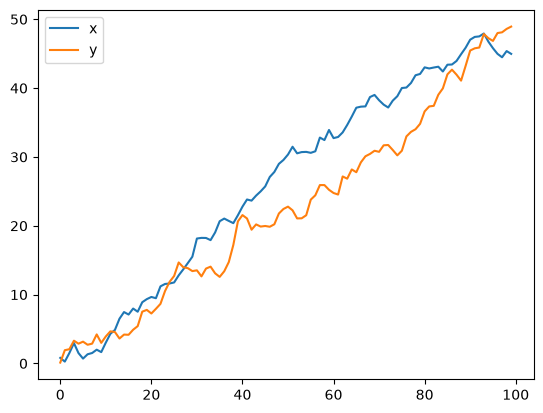

In [2]:
rng = np.random.default_rng(42)
n = 100
derive = 0.5
x = np.cumsum(derive + rng.normal(0, 1, n))
y = np.cumsum(derive + rng.normal(0, 1, n))

plt.plot(x, label="x")
plt.plot(y, label="y")
plt.legend()
plt.show()

Les deux montent, forcément (dérive positive). Corrélation brute :

In [3]:
np.corrcoef(x, y)[0, 1]

np.float64(0.969719734581185)

## 2. OLS en niveaux

In [4]:
X = sm.add_constant(x)
modele_niveaux = sm.OLS(y, X).fit()
print(modele_niveaux.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     1545.
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           8.34e-62
Time:                        03:17:09   Log-Likelihood:                -265.05
No. Observations:                 100   AIC:                             534.1
Df Residuals:                      98   BIC:                             539.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2038      0.696     -1.729      0.0

R² énorme, t-stat énorme. Mais le Durbin-Watson est très faible, signe classique (Granger & Newbold) :
quand R² > DW, il faut se méfier.

In [5]:
print("R² =", round(modele_niveaux.rsquared, 3), " DW =", round(durbin_watson(modele_niveaux.resid), 3))

R² = 0.94  DW = 0.112


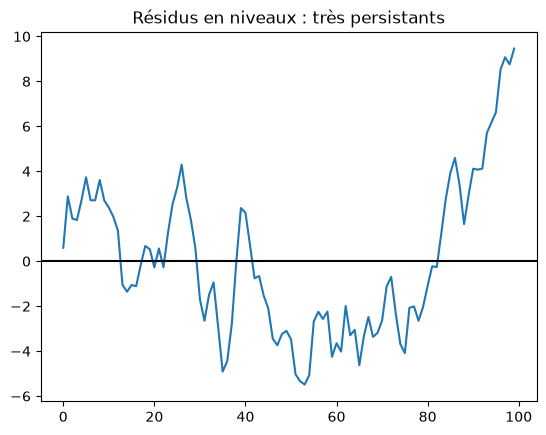

In [6]:
plt.plot(modele_niveaux.resid)
plt.axhline(0, color="black")
plt.title("Résidus en niveaux : très persistants")
plt.show()

## 3. Test ADF
H0 : racine unitaire (non stationnaire). On veut voir p > 0.05 en niveaux, p < 0.05 en différences.
Pour une série avec dérive, je teste avec `regression="ct"` (constante + tendance) et aussi `"c"` pour comparer.

In [7]:
for nom, serie in [("x", x), ("y", y)]:
    p_c = adfuller(serie, regression="c", result_object=False)[1]
    p_ct = adfuller(serie, regression="ct", result_object=False)[1]
    p_diff = adfuller(np.diff(serie), regression="c", result_object=False)[1]
    print(f"{nom} : p niveaux (c) = {p_c:.3f} | p niveaux (ct) = {p_ct:.3f} | p différences = {p_diff:.4f}")

x : p niveaux (c) = 0.507 | p niveaux (ct) = 1.000 | p différences = 0.0000
y : p niveaux (c) = 0.992 | p niveaux (ct) = 0.122 | p différences = 0.0000


Les deux spécifications concluent à la non-stationnarité en niveaux (p > 0.05), et les différences sont
stationnaires (p ≈ 0). Comme les séries ont une dérive, je garde `"ct"` en niveaux et `"c"` en différences.

Remarque : statsmodels 0.15 affiche un FutureWarning sur le format de sortie de `adfuller`,
d'où `result_object=False`.

## 4. OLS en différences premières

In [8]:
dx, dy = np.diff(x), np.diff(y)
modele_diff = sm.OLS(dy, sm.add_constant(dx)).fit()
print(modele_diff.summary().tables[1])
print("R² =", round(modele_diff.rsquared, 3), " DW =", round(durbin_watson(modele_diff.resid), 3))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4388      0.114      3.846      0.000       0.212       0.665
x1             0.1216      0.127      0.954      0.342      -0.131       0.375
R² = 0.009  DW = 1.648


Plus rien. DW proche de 2, résidus « normaux ».

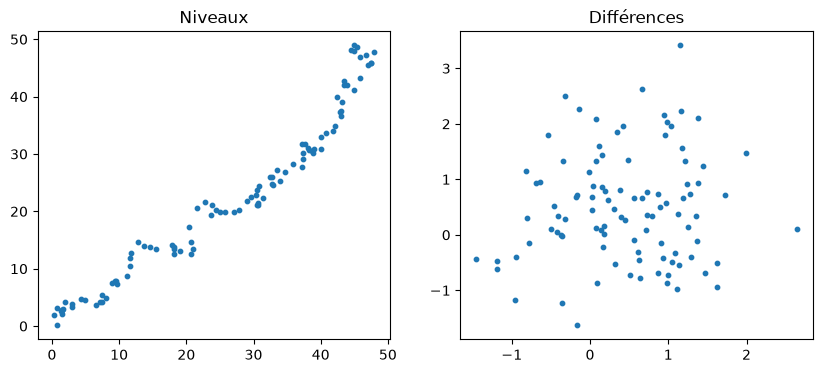

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(x, y, s=10)
axes[0].set_title("Niveaux")
axes[1].scatter(dx, dy, s=10)
axes[1].set_title("Différences")
plt.show()

## 5. Monte Carlo
Premier essai avec une boucle simple, 500 répétitions.

In [10]:
def une_repetition(rng, n=100, derive=0.5):
    x = np.cumsum(derive + rng.normal(0, 1, n))
    y = np.cumsum(derive + rng.normal(0, 1, n))
    t_niv = sm.OLS(y, sm.add_constant(x)).fit().tvalues[1]
    t_dif = sm.OLS(np.diff(y), sm.add_constant(np.diff(x))).fit().tvalues[1]
    return t_niv, t_dif

rng = np.random.default_rng(0)
res = np.array([une_repetition(rng) for _ in range(500)])
t_niveaux, t_diff = res[:, 0], res[:, 1]
print("% significatif en niveaux     :", np.mean(np.abs(t_niveaux) > 1.96) * 100)
print("% significatif en différences :", np.mean(np.abs(t_diff) > 1.96) * 100)

% significatif en niveaux     : 100.0
% significatif en différences : 4.3999999999999995


~5 % en différences (c'est le risque de première espèce, normal). En niveaux, presque toujours significatif.

J'ai utilisé |t| > 1.96 ; avec les p-values exactes (loi de Student) ça change à peine. Vérif :

In [11]:
def une_repetition_pval(rng, n=100, derive=0.5):
    x = np.cumsum(derive + rng.normal(0, 1, n))
    y = np.cumsum(derive + rng.normal(0, 1, n))
    p_niv = sm.OLS(y, sm.add_constant(x)).fit().pvalues[1]
    p_dif = sm.OLS(np.diff(y), sm.add_constant(np.diff(x))).fit().pvalues[1]
    return p_niv, p_dif

rng = np.random.default_rng(0)
pv = np.array([une_repetition_pval(rng) for _ in range(500)])
print((pv < 0.05).mean(axis=0) * 100)

[100.    4.2]


Même chose. Je garderai les p-values dans le code final, c'est plus propre.

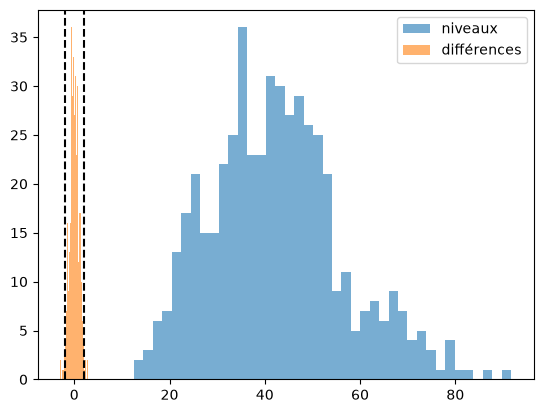

In [12]:
plt.hist(t_niveaux, bins=40, alpha=0.6, label="niveaux")
plt.hist(t_diff, bins=40, alpha=0.6, label="différences")
plt.axvline(1.96, color="k", ls="--")
plt.axvline(-1.96, color="k", ls="--")
plt.legend()
plt.show()

Les t-stats en niveaux sont énormes (dizaines), l'histogramme écrase les différences.
Pour la figure finale : deux panneaux séparés, sinon on ne voit rien.

## 6. Et sans dérive ?
Granger & Newbold (1974) utilisaient des marches aléatoires pures. Est-ce que le problème existe aussi ?

In [13]:
rng = np.random.default_rng(1)
pv0 = np.array([une_repetition_pval(rng, derive=0.0) for _ in range(500)])
print("sans dérive :", (pv0 < 0.05).mean(axis=0) * 100)

sans dérive : [73.8  4.8]


Oui : environ 75 % de faux positifs sans dérive. La dérive aggrave le problème mais n'est pas nécessaire.
C'est la non-stationnarité qui pose problème.

## 7. Effet de la taille d'échantillon
Idée de figure supplémentaire : est-ce que plus de données règle le problème ? (intuition : non, ça empire)

In [14]:
tailles = [25, 50, 100, 200, 500, 1000]
rng = np.random.default_rng(2)
lignes = []
for taille in tailles:
    pv_n = np.array([une_repetition_pval(rng, n=taille) for _ in range(300)])
    lignes.append([taille, *((pv_n < 0.05).mean(axis=0) * 100)])
pd.DataFrame(lignes, columns=["n", "% niveaux", "% différences"])

,n,% niveaux,% différences
0,25,95.666667,5.666667
1,50,99.666667,6.000000
2,100,100.000000,6.000000
3,200,100.000000,6.666667
4,500,100.000000,4.666667
5,1000,100.000000,5.000000


Avec dérive, c'est déjà ~100 % dès n = 50 : la courbe est plate, pas très parlante.
Même chose sans dérive (cas Granger & Newbold) :

In [15]:
rng = np.random.default_rng(3)
lignes0 = []
for taille in tailles:
    pv_n = np.array([une_repetition_pval(rng, n=taille, derive=0.0) for _ in range(300)])
    lignes0.append([taille, *((pv_n < 0.05).mean(axis=0) * 100)])
pd.DataFrame(lignes0, columns=["n", "% niveaux", "% différences"])

,n,% niveaux,% différences
0,25,50.666667,3.666667
1,50,67.333333,4.000000
2,100,74.000000,5.666667
3,200,81.666667,5.333333
4,500,88.666667,6.333333
5,1000,93.333333,5.666667


Sans dérive, le taux de faux positifs en niveaux **augmente avec n** (la t-stat diverge quand n grandit).
Plus de données ne protège pas d'une mauvaise spécification. En différences, on reste autour de 5 %.
→ Pour cette figure j'utiliserai les deux cas (avec et sans dérive), c'est plus instructif.

## Bilan pour `src/`
- `simulation.py` : une fonction qui renvoie deux marches aléatoires (n, dérive, seed).
- `analyse.py` : `regression_ols` (pente, t, p, R², DW), `test_adf`, `monte_carlo_fallacieux`, `taux_selon_n` (avec un argument dérive).
- `graphiques.py` : séries superposées (titre drôle), nuages niveaux vs différences, résidus,
  histogramme des t-stats en 2 panneaux, taux de faux positifs selon n.
- ADF : `"ct"` en niveaux, `"c"` en différences.
- Critère de significativité : p-value < 0.05.